


Este notebook aplica mineração de dados a um dataset de **51 problemas de SQL**
da plataforma Beecrowd , anotados com **21 conceitos de SQL** e atributos de
identificação, popularidade e complexidade.


## 0. Ambiente (Google Colab)


In [1]:
# Dataset embutido: recria o arquivo CSV no ambiente (dispensa upload/download)
import base64, gzip, hashlib

_CSV_B64 = (
    "..."
)

_dados = gzip.decompress(base64.b64decode(_CSV_B64))
assert hashlib.sha256(_dados).hexdigest() == "8a12eb82a576dd7128c671dd53c82789bded032af43d0bb6a0fcaa8e5dd4c935", "Conteúdo do CSV corrompido"
with open("dataset_beecrowd_refinado-final.csv", "wb") as _f:
    _f.write(_dados)
print("CSV recriado:", len(_dados), "bytes")

CSV recriado: 117842 bytes


In [2]:
!pip -q install mlxtend

import os, warnings
warnings.filterwarnings("ignore")

CSV = "dataset_beecrowd_refinado-final.csv"

if os.path.exists(CSV):
    print("Dataset disponível: True")
else:
    print("Dataset disponível: False")
    print()
    print(f"O arquivo '{CSV}' ainda não está no ambiente.")
    print("Carregue-o pelo painel de Arquivos (ícone de pasta 📁 -> botão de upload ⬆)")
    print("e execute esta célula novamente.")

Dataset disponível: True


## 1. Configuração e carga dos dados


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.stats import pearsonr, spearmanr
from mlxtend.frequent_patterns import apriori, association_rules

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

CSV = "dataset_beecrowd_refinado-final.csv"
df = pd.read_csv(CSV)

_aux = [c for c in ["cluster_k2", "cluster_k3"] if c in df.columns]
if _aux:
    df = df.drop(columns=_aux)
    print("Colunas auxiliares removidas:", _aux)
print("Dimensões:", df.shape)
df.head(3)

Dimensões: (51, 36)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,problema_id,titulo,autor,url,enunciado,nivel,num_resolvidos,num_conceitos_total,faixa_conceitual,conceito_primario,conceitos_lista,usa_where,usa_order_by,usa_distinct,usa_like,usa_in,usa_between,usa_agregacao,usa_join,usa_group_by,usa_having,usa_subconsulta,usa_subconsulta_correlacionada,usa_union,usa_case,usa_funcao_data,usa_tratamento_null,usa_cast,usa_recursao,usa_funcao_janela,usa_pivot,usa_funcao_string,sql_entrada,sql_saida,complexidade_tecnica,discrepancia_nivel_complexidade
0,2602,Select Básico,Paulo R. Rodegheri,https://judge.beecrowd.com/pt/problems/view/2602,Sua empresa está fazendo um levantamento de qu...,4,41417,1,Básico,WHERE,WHERE,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,--- URI Online Judge SQL\n--- Copyright URI On...,SELECT name from customers where state= 'RS';,1,1.067095
1,2603,Endereço dos Clientes,Paulo R. Rodegheri,https://judge.beecrowd.com/pt/problems/view/2603,A empresa fará um evento comemorando os 20 ano...,1,36554,1,Básico,WHERE,WHERE,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,--- URI Online Judge SQL\n--- Copyright URI On...,"SELECT name,street from customers where city =...",1,-0.405558
2,2604,Menores que 10 ou Maiores que 100,Paulo R. Rodegheri,https://judge.beecrowd.com/pt/problems/view/2604,O setor financeiro da empresa precisa de um re...,2,32834,1,Básico,WHERE,WHERE,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,--- URI Online Judge SQL\n--- Copyright URI On...,"SELECT id,name FROM products where price < 10 ...",1,0.085327


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [4]:
usa_cols = [c for c in df.columns if c.startswith("usa_")]
print(f"{len(usa_cols)} conceitos anotados")

ROTULO = {
    "usa_where": "WHERE", "usa_order_by": "ORDER BY", "usa_distinct": "DISTINCT",
    "usa_like": "LIKE", "usa_in": "IN", "usa_between": "BETWEEN",
    "usa_agregacao": "Agregação", "usa_join": "JOIN", "usa_group_by": "GROUP BY",
    "usa_having": "HAVING", "usa_subconsulta": "Subconsulta",
    "usa_subconsulta_correlacionada": "Subcons. correl.", "usa_union": "UNION",
    "usa_case": "CASE", "usa_funcao_data": "Função de data",
    "usa_tratamento_null": "Tratamento de NULL", "usa_cast": "CAST",
    "usa_recursao": "Recursão", "usa_funcao_janela": "Função de janela",
    "usa_pivot": "PIVOT", "usa_funcao_string": "Função de string",
}
def rotular(cols):
    return [ROTULO.get(c, c) for c in cols]

# --- Níveis técnicos dos conceitos (referência curricular) ---
# Usados tanto para a classificação em faixas quanto para a complexidade técnica.
CONCEITOS_BASICOS = ["usa_where", "usa_order_by", "usa_distinct", "usa_like",
                     "usa_in", "usa_between", "usa_funcao_string"]
CONCEITOS_INTERM  = ["usa_agregacao", "usa_join", "usa_group_by", "usa_having",
                     "usa_case", "usa_union", "usa_cast", "usa_funcao_data",
                     "usa_tratamento_null"]
CONCEITOS_AVANC   = ["usa_subconsulta", "usa_subconsulta_correlacionada",
                     "usa_recursao", "usa_funcao_janela", "usa_pivot"]
# mantém apenas os conceitos efetivamente presentes no dataset
CONCEITOS_BASICOS = [c for c in CONCEITOS_BASICOS if c in usa_cols]
CONCEITOS_INTERM  = [c for c in CONCEITOS_INTERM  if c in usa_cols]
CONCEITOS_AVANC   = [c for c in CONCEITOS_AVANC   if c in usa_cols]
assert len(CONCEITOS_BASICOS)+len(CONCEITOS_INTERM)+len(CONCEITOS_AVANC) == len(usa_cols), \
    "A partição em níveis não cobre todos os conceitos!"
print(f"Níveis: {len(CONCEITOS_BASICOS)} básicos, {len(CONCEITOS_INTERM)} intermediários, "
      f"{len(CONCEITOS_AVANC)} avançados")


21 conceitos anotados
Níveis: 7 básicos, 9 intermediários, 5 avançados


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

### 1.1 Complexidade técnica e discrepância

A **complexidade técnica** de cada problema é recalculada a partir da matriz problema–conceito
como uma soma ponderada dos conceitos por nível técnico:

$$CT = 1 \cdot b + 2 \cdot i + 3 \cdot a$$

onde $b$, $i$ e $a$ são os números de conceitos básicos, intermediários e avançados exigidos na
solução. A **discrepância** entre o nível declarado e a complexidade técnica usa as duas grandezas
padronizadas (escore $z$), para que fiquem na mesma escala:

$$D = z(\text{nível}) - z(CT)$$

Valores positivos indicam nível superestimado; negativos, subestimado.


In [5]:
# --- Complexidade técnica: CT = 1*b + 2*i + 3*a ---
b = df[CONCEITOS_BASICOS].sum(axis=1)
i = df[CONCEITOS_INTERM].sum(axis=1)
a = df[CONCEITOS_AVANC].sum(axis=1)

PESOS = (1, 2, 3)  # (básico, intermediário, avançado)
df["complexidade_tecnica"] = PESOS[0]*b + PESOS[1]*i + PESOS[2]*a

# --- Discrepância: D = z(nível) - z(CT) ---
def zscore(s):
    return (s - s.mean()) / s.std(ddof=0)

df["discrepancia_nivel_complexidade"] = zscore(df["nivel"]) - zscore(df["complexidade_tecnica"])

print("Complexidade técnica:")
print(df["complexidade_tecnica"].describe().round(2).to_string())
print("\nDiscrepância  D = z(nível) - z(CT):")
print(df["discrepancia_nivel_complexidade"].describe().round(3).to_string())


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Complexidade técnica:
count    51.00
mean      5.76
std       5.38
min       1.00
25%       2.50
50%       4.00
75%       6.00
max      21.00

Discrepância  D = z(nível) - z(CT):
count    51.000
mean      0.000
std       0.982
min      -3.595
25%      -0.406
50%       0.085
75%       0.692
max       1.674


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

## 2. Pré-processamento e verificação de qualidade


In [6]:
info = pd.DataFrame({"dtype": df.dtypes.astype(str), "n_nulos": df.isna().sum()})
print("Colunas com valores ausentes:")
print(info[info.n_nulos > 0] if info.n_nulos.sum() else "  (nenhuma)")

soma_flags = df[usa_cols].sum(axis=1)
inconsistentes = int((df["num_conceitos_total"] != soma_flags).sum())
orfaos = int((soma_flags == 0).sum())
print(f"\nLinhas inconsistentes (total != soma flags): {inconsistentes}")
print(f"Problemas sem nenhum conceito (órfãos): {orfaos}")
assert inconsistentes == 0 and orfaos == 0, "Falha de integridade no dataset!"
print("Integridade OK.")

Colunas com valores ausentes:
  (nenhuma)

Linhas inconsistentes (total != soma flags): 0
Problemas sem nenhum conceito (órfãos): 0
Integridade OK.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [7]:
num_cols = ["nivel", "num_resolvidos", "num_conceitos_total",
            "complexidade_tecnica", "discrepancia_nivel_complexidade"]
df[num_cols].describe().T.round(3)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,count,mean,std,min,25%,50%,75%,max
nivel,51.0,3.647,2.057,1.000,2.000,3.000,5.000,9.000
num_resolvidos,51.0,10540.529,9846.373,50.000,2655.500,7175.000,14521.500,41417.000
num_conceitos_total,51.0,3.353,2.448,1.000,2.000,3.000,4.000,10.000
complexidade_tecnica,51.0,5.765,5.384,1.000,2.500,4.000,6.000,21.000
discrepancia_nivel_complexidade,51.0,0.000,0.982,-3.595,-0.406,0.085,0.692,1.674


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 3. Análise exploratória (EDA)


### 3.1 Cobertura conceitual — quantos problemas exercitam cada conceito? (QP3)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

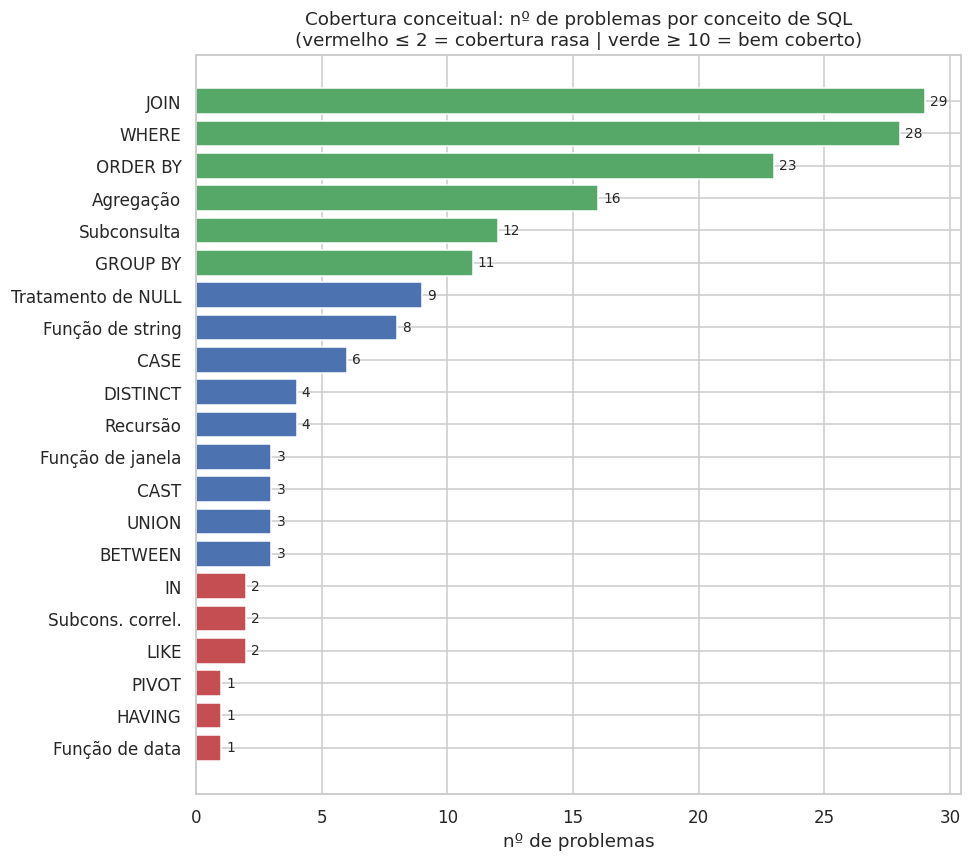

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [8]:
freq = df[usa_cols].sum().sort_values(ascending=True)
freq.index = rotular(freq.index)

plt.figure(figsize=(9, 8))
cores = ["#C44E52" if v <= 2 else "#55A868" if v >= 10 else "#4C72B0" for v in freq.values]
plt.barh(freq.index, freq.values, color=cores)
for i, v in enumerate(freq.values):
    plt.text(v + 0.2, i, str(int(v)), va="center", fontsize=9)
plt.title("Cobertura conceitual: nº de problemas por conceito de SQL\n"
          "(vermelho ≤ 2 = cobertura rasa | verde ≥ 10 = bem coberto)")
plt.xlabel("nº de problemas"); plt.tight_layout(); plt.show()

### 3.2 Distribuição dos conceitos por faixa conceitual (Figura 2)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

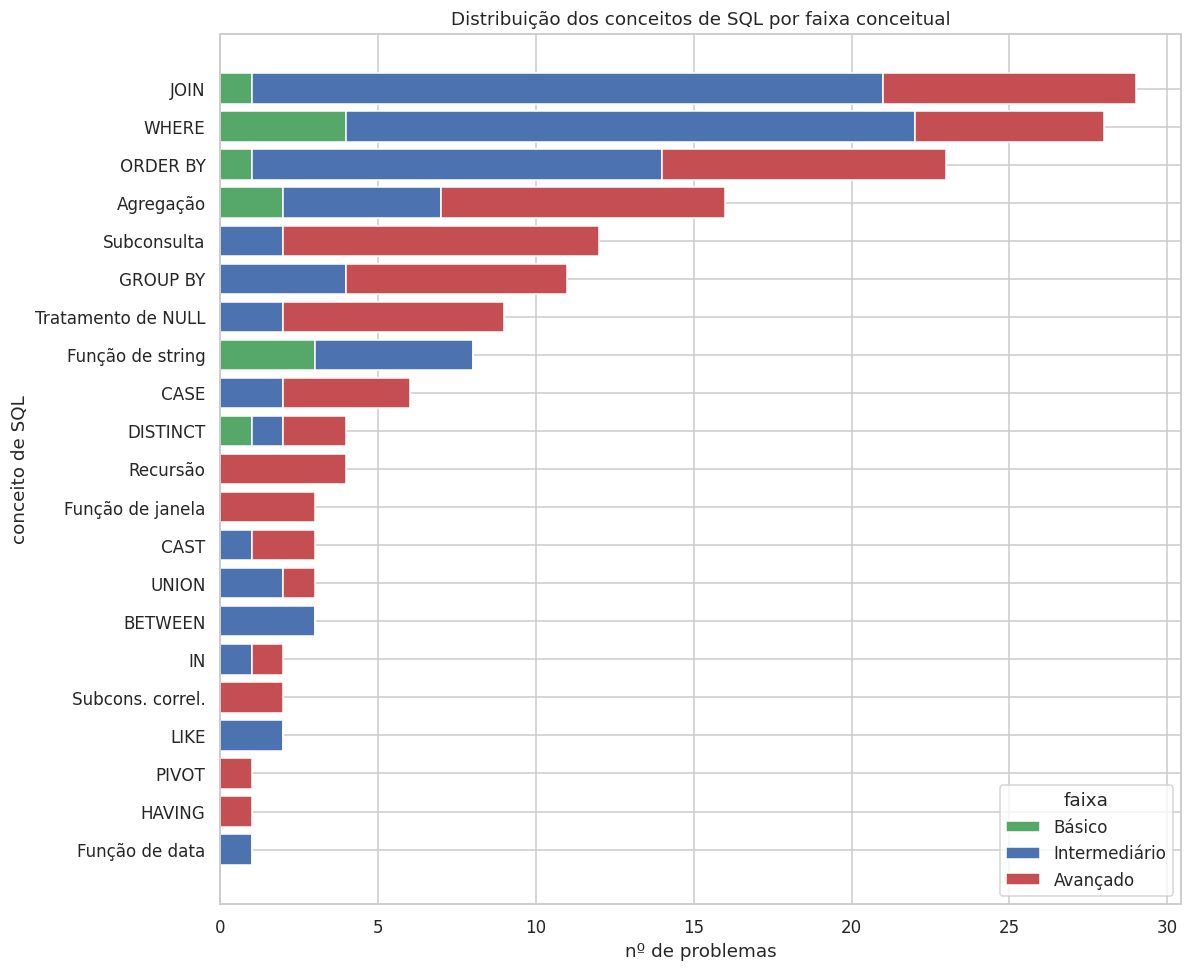

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [9]:
# Figura 2 — para cada conceito, quantos problemas o exercitam em cada faixa
ordem = ["Básico", "Intermediário", "Avançado"]
cores = {"Básico": "#55A868", "Intermediário": "#4C72B0", "Avançado": "#C44E52"}

# contagem conceito x faixa
dist = []
for c in usa_cols:
    linha = {"conceito": ROTULO.get(c, c)}
    for f in ordem:
        linha[f] = int(df.loc[df["faixa_conceitual"] == f, c].sum())
    dist.append(linha)
dist = pd.DataFrame(dist).set_index("conceito")
dist["_tot"] = dist.sum(axis=1)
dist = dist.sort_values("_tot", ascending=True).drop(columns="_tot")

fig, ax = plt.subplots(figsize=(11, 9))
esq = [0]*len(dist)
for f in ordem:
    ax.barh(dist.index, dist[f], left=esq, color=cores[f], label=f, edgecolor="white")
    esq = [e + v for e, v in zip(esq, dist[f])]
ax.set_xlabel("nº de problemas")
ax.set_ylabel("conceito de SQL")
ax.set_title("Distribuição dos conceitos de SQL por faixa conceitual")
ax.legend(title="faixa", loc="lower right")
plt.tight_layout(); plt.show()


### 3.3 Validação da classificação em faixas — Figuras 3 e 4


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Coerência faixa × conceitos complexos:
  'Básico' que usam conceito avançado : 0  (esperado 0)
  'Avançado' sem conceito complexo    : 0  (esperado 0)
  Média de conceitos avançados por faixa:
faixa_conceitual
Básico           0.00
Intermediário    0.07
Avançado         2.00


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

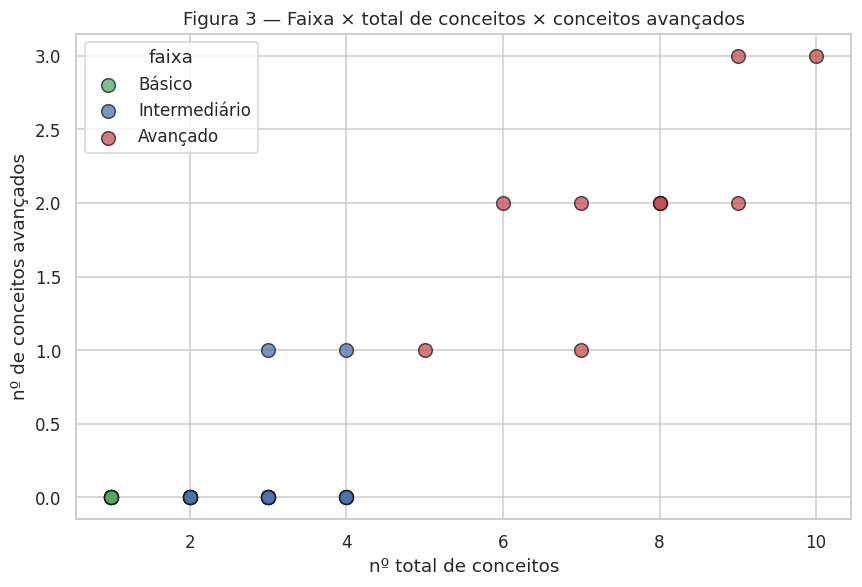

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

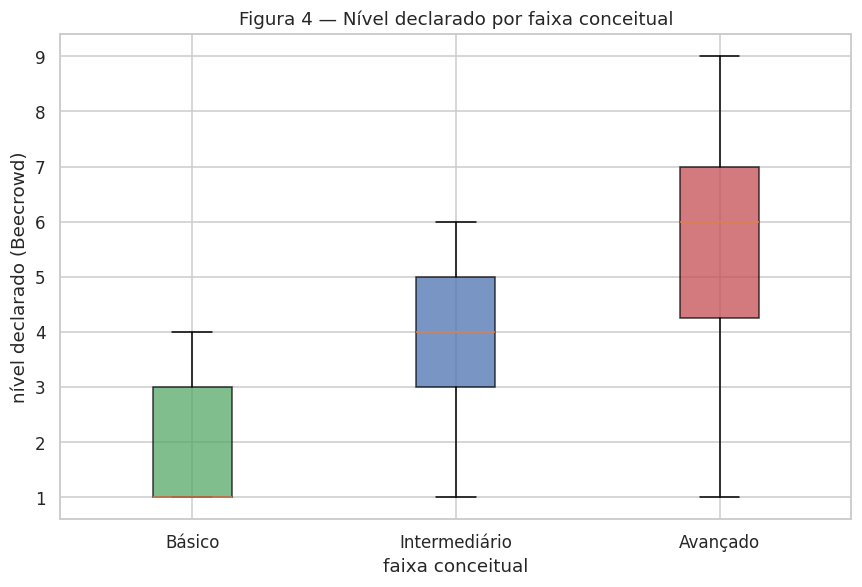

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [10]:
ordem = ["Básico", "Intermediário", "Avançado"]
AVANCADOS = ["usa_subconsulta", "usa_subconsulta_correlacionada",
             "usa_recursao", "usa_funcao_janela", "usa_pivot"]
AVANCADOS = [c for c in AVANCADOS if c in df.columns]
df["_n_avancados"] = df[AVANCADOS].sum(axis=1)

inconsist_basico = df[(df["faixa_conceitual"] == "Básico") & (df["_n_avancados"] > 0)]
inconsist_avanc  = df[(df["faixa_conceitual"] == "Avançado") & (df["_n_avancados"] == 0)]
print("Coerência faixa × conceitos complexos:")
print(f"  'Básico' que usam conceito avançado : {len(inconsist_basico)}  (esperado 0)")
print(f"  'Avançado' sem conceito complexo    : {len(inconsist_avanc)}  (esperado 0)")
print("  Média de conceitos avançados por faixa:")
print(df.groupby('faixa_conceitual')['_n_avancados'].mean().reindex(ordem).round(2).to_string())

cores = {"Básico": "#55A868", "Intermediário": "#4C72B0", "Avançado": "#C44E52"}

# --- Figura 3: faixa × total de conceitos × conceitos avançados ---
fig3, ax3 = plt.subplots(figsize=(8, 5.5))
for f in ordem:
    d = df[df["faixa_conceitual"] == f]
    ax3.scatter(d["num_conceitos_total"], d["_n_avancados"],
                label=f, color=cores[f], s=80, edgecolor="k", alpha=0.75)
ax3.set_xlabel("nº total de conceitos"); ax3.set_ylabel("nº de conceitos avançados")
ax3.set_title("Figura 3 — Faixa × total de conceitos × conceitos avançados")
ax3.legend(title="faixa")
plt.tight_layout(); plt.show()

# --- Figura 4: nível declarado por faixa conceitual ---
fig4, ax4 = plt.subplots(figsize=(8, 5.5))
dados = [df[df["faixa_conceitual"] == f]["nivel"] for f in ordem]
bp = ax4.boxplot(dados, tick_labels=ordem, patch_artist=True)
for patch, f in zip(bp["boxes"], ordem):
    patch.set_facecolor(cores[f]); patch.set_alpha(0.75)
ax4.set_ylabel("nível declarado (Beecrowd)"); ax4.set_xlabel("faixa conceitual")
ax4.set_title("Figura 4 — Nível declarado por faixa conceitual")
plt.tight_layout(); plt.show()

df.drop(columns=["_n_avancados"], inplace=True)


## 4. Demonstração visual PROBLEMA × CONCEITO (núcleo pedagógico)


### 4.1 Matriz problema × conceito (heatmap)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

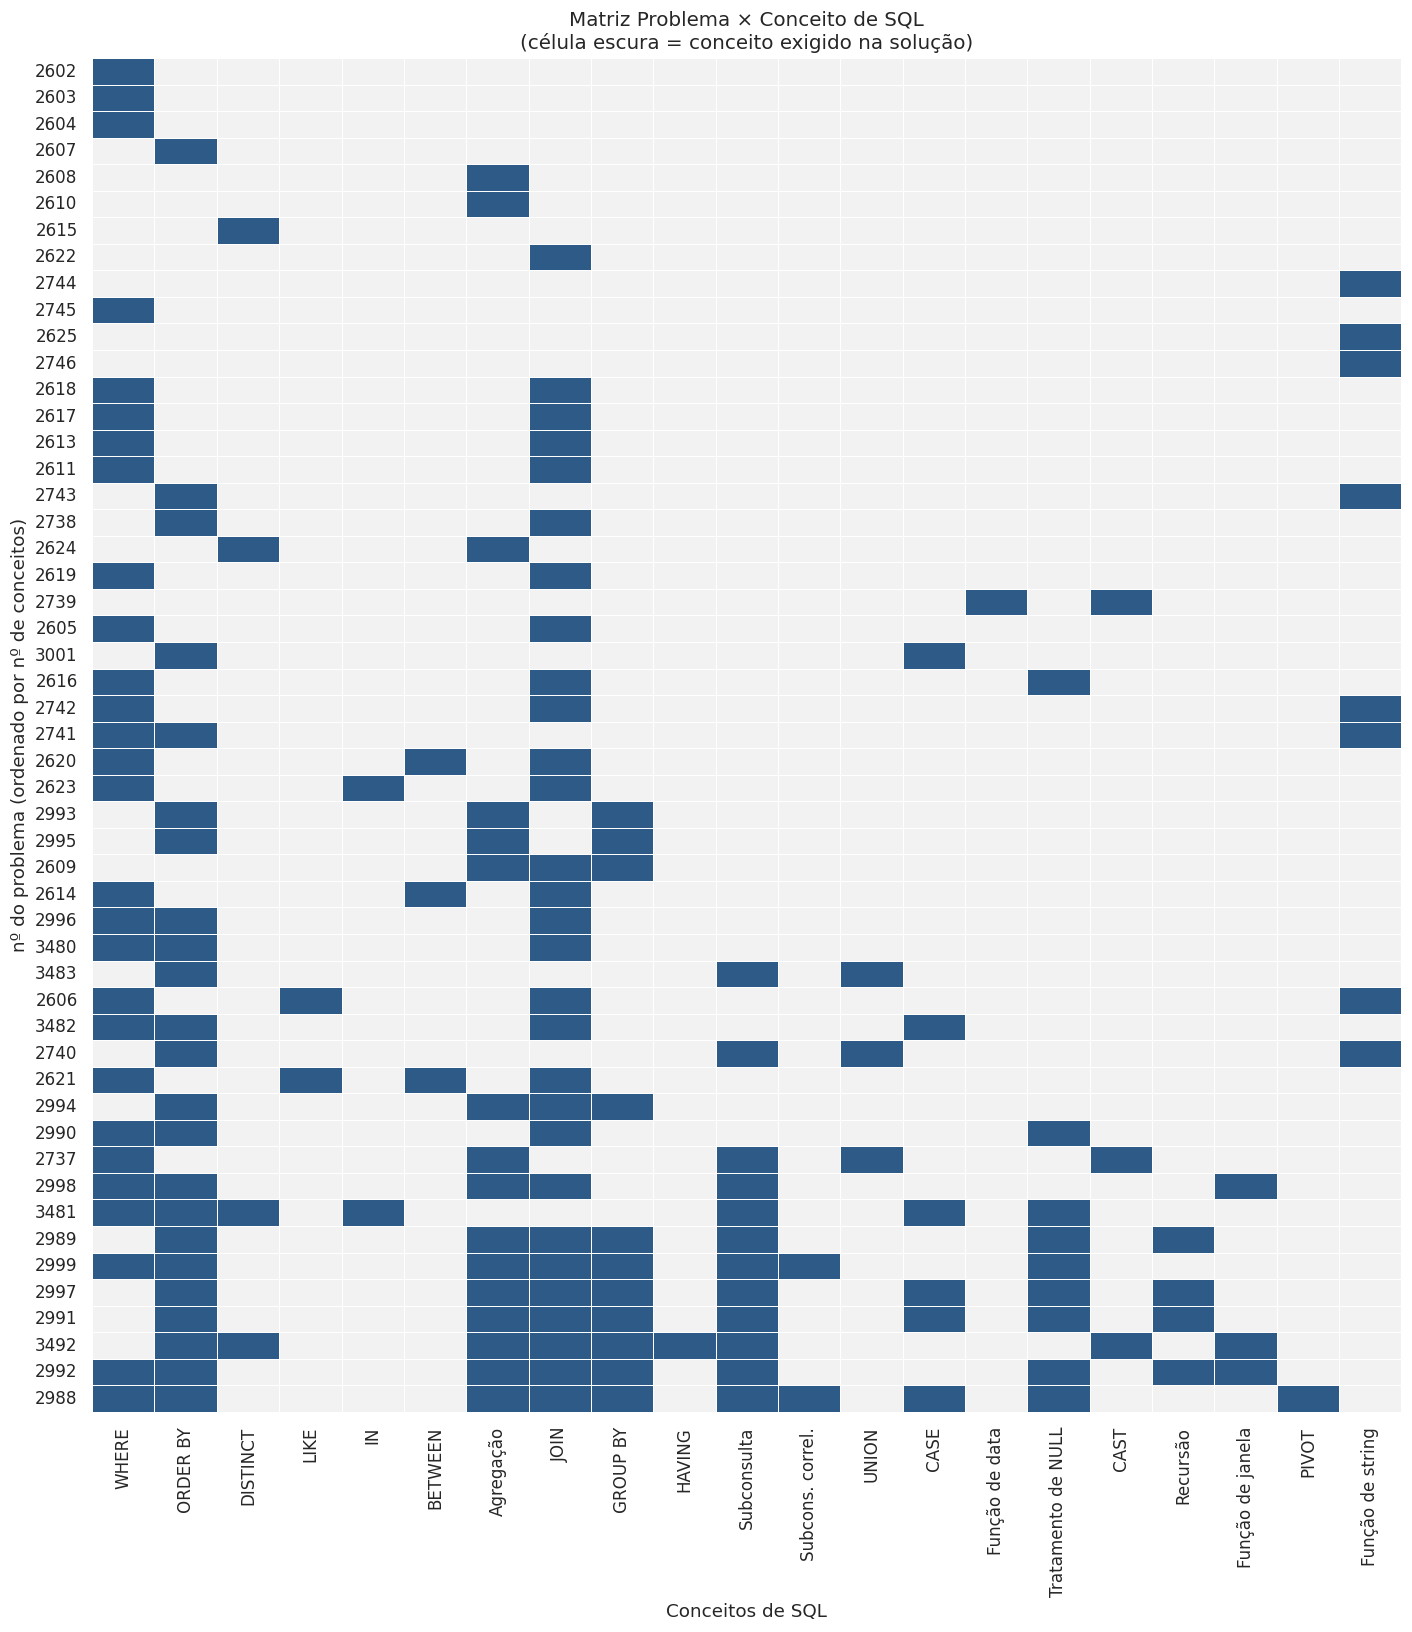

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [11]:
# Matriz problema × conceito — eixo Y = nº que identifica o problema (problema_id)
mat = df.sort_values("num_conceitos_total").set_index("problema_id")[usa_cols]
mat.columns = rotular(mat.columns)

plt.figure(figsize=(13, 15))
sns.heatmap(mat, cmap=["#F2F2F2", "#2E5A87"], cbar=False, linewidths=0.4, linecolor="white")
plt.title("Matriz Problema × Conceito de SQL\n(célula escura = conceito exigido na solução)", fontsize=13)
plt.xlabel("Conceitos de SQL"); plt.ylabel("nº do problema (ordenado por nº de conceitos)")
plt.tight_layout(); plt.show()


### 4.2 Co-ocorrência de conceitos — quais conceitos aparecem juntos no mesmo SELECT?


In [ ]:
M = df[usa_cols].values
coocc = np.array(M.T @ M, dtype=int)
labels = rotular(usa_cols)
cooc_df = pd.DataFrame(coocc, index=labels, columns=labels)
for lab in labels:
    cooc_df.loc[lab, lab] = 0

plt.figure(figsize=(13, 11))
sns.heatmap(cooc_df, cmap="YlOrRd", annot=True, fmt="d", annot_kws={"size": 7},
            linewidths=0.3, cbar_kws={"label": "nº de problemas em que coexistem"})
plt.title("Co-ocorrência de conceitos no mesmo problema (SELECT)")
plt.tight_layout(); plt.show()

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

### 4.3 Densidade conceitual — problemas-síntese (Top 15)


In [ ]:
top = df.nlargest(10, "num_conceitos_total")[
    ["problema_id", "titulo", "nivel", "num_conceitos_total", "conceito_primario", "conceitos_lista"]
].reset_index(drop=True)
display(top)

plt.figure(figsize=(11, 6))
d = df.sort_values("num_conceitos_total", ascending=True).tail(10)
plt.barh(d["titulo"], d["num_conceitos_total"], color="#8172B3")
for i, v in enumerate(d["num_conceitos_total"]):
    plt.text(v + 0.1, i, f"{int(v)}", va="center", fontsize=9)
plt.title("Top 10 problemas por nº de conceitos combinados no mesmo SELECT")
plt.xlabel("nº de conceitos"); plt.tight_layout(); plt.show()


### 4.4 Mapa de escolha: conceito primário × faixa de complexidade


In [ ]:
pivot = pd.crosstab(df["conceito_primario"], df["faixa_conceitual"])
pivot = pivot.reindex(columns=["Básico", "Intermediário", "Avançado"], fill_value=0)
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(8, 9))
sns.heatmap(pivot, annot=True, fmt="d", cmap="Blues", linewidths=0.5,
            cbar_kws={"label": "nº de problemas"})
plt.title("Mapa de escolha: conceito primário × faixa de complexidade")
plt.ylabel("Conceito primário (tópico mais avançado do problema)"); plt.xlabel("Faixa")
plt.tight_layout(); plt.show()
pivot

## 5. Aprendizado de Máquina I — Clusterização (K-Means)


In [ ]:
# Features da clusterização: APENAS o perfil conceitual (as 21 flags usa_*).
# O nível declarado (nivel) NÃO entra na formação dos clusters — ele é usado
# somente A POSTERIORI (Seção 5.2), para comparar os grupos descobertos com a
# dificuldade declarada pela plataforma. Isso evita circularidade, já que a QP2
# justamente avalia se o nível declarado é coerente com a complexidade real.
features = list(usa_cols)  # sem "nivel"
X = df[features].fillna(0).astype(float)
X_scaled = StandardScaler().fit_transform(X)
print("Matriz de features (somente conceitos, sem nível):", X_scaled.shape)


### 5.1 Análise de hiperparâmetros — escolha de *k*


In [ ]:
ks = range(2, 8)
inercias, silhuetas = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
    inercias.append(km.inertia_)
    silhuetas.append(silhouette_score(X_scaled, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(list(ks), inercias, "o-", color="#4C72B0"); ax[0].set_title("Método do cotovelo (inércia)")
ax[0].set_xlabel("k"); ax[0].set_ylabel("inércia")
ax[1].plot(list(ks), silhuetas, "o-", color="#C44E52"); ax[1].set_title("Coeficiente de silhueta")
ax[1].set_xlabel("k"); ax[1].set_ylabel("silhueta")
plt.tight_layout(); plt.show()

for k, s in zip(ks, silhuetas):
    print(f"k={k}: silhueta={s:.3f}")
melhor_k = list(ks)[int(np.argmax(silhuetas))]
print(f"\nMelhor k pela silhueta: {melhor_k}")

### 5.2 Ajuste final e perfil dos clusters


In [ ]:
k = 3
km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)

tmp = df.copy(); tmp["_lab"] = km.labels_
ordem_l = tmp.groupby("_lab")["num_conceitos_total"].mean().sort_values().index
remap = {c: i for i, c in enumerate(ordem_l)}
df["cluster_final"] = [remap[l] for l in km.labels_]

perfil = df.groupby("cluster_final").agg(
    n=("problema_id", "count"),
    nivel_medio=("nivel", "mean"),
    conceitos_medio=("num_conceitos_total", "mean"),
    resolvidos_medio=("num_resolvidos", "mean"),
    complexidade_media=("complexidade_tecnica", "mean"),
).round(2)
perfil

### 5.3 Visualização dos clusters via PCA (2D)


In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)
var = pca.explained_variance_ratio_

plt.figure(figsize=(9, 7))
sc = plt.scatter(coords[:, 0], coords[:, 1], c=df["cluster_final"],
                 cmap="Set1", s=90, edgecolor="k", alpha=0.85)
for i, r in df.iterrows():
    if r["num_conceitos_total"] >= 8:
        plt.annotate(str(r["titulo"])[:18], (coords[i, 0], coords[i, 1]),
                     fontsize=7, alpha=0.7, xytext=(3, 3), textcoords="offset points")
plt.title(f"Clusters de problemas (PCA 2D)\n"
          f"variância explicada: PC1={var[0]:.0%}, PC2={var[1]:.0%}")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.colorbar(sc, label="cluster (0=simples → 2=complexo)")
plt.tight_layout(); plt.show()

## 6. Aprendizado de Máquina II — Regras de Associação (Apriori)


### 6.1 Itemsets frequentes e geração das regras


In [ ]:
cesta = df[usa_cols].astype(bool)
cesta.columns = rotular(usa_cols)

freq_is = apriori(cesta, min_support=0.12, use_colnames=True, max_len=3)
print(f"Itemsets frequentes (sup≥0.12, até 3 itens): {len(freq_is)}")

regras = association_rules(freq_is, metric="confidence", min_threshold=0.6)
regras = regras[regras["lift"] > 1.2].copy()
regras["n_ant"] = regras["antecedents"].apply(len)
regras["n_con"] = regras["consequents"].apply(len)
regras = regras[(regras["n_ant"] <= 2) & (regras["n_con"] == 1)]
regras = regras.sort_values(["lift", "confidence"], ascending=False).reset_index(drop=True)

def _fmt(itemset): return " + ".join(sorted(itemset))
regras["Antecedente"] = regras["antecedents"].apply(_fmt)
regras["Consequente"] = regras["consequents"].apply(_fmt)

tabela = regras[["Antecedente", "Consequente", "support", "confidence", "lift"]].round(3)
tabela.columns = ["Antecedente", "Consequente", "Suporte", "Confiança", "Lift"]
print(f"Regras robustas e interpretáveis: {len(tabela)}")
display(tabela.head(15))

### 6.2 Visualização — Top 12 regras por lift (Figura 9)


In [ ]:
# Figura 9 — apenas o gráfico de lift (Top 12 regras)
top_r = regras.head(12).iloc[::-1]
rot = top_r["Antecedente"] + "  →  " + top_r["Consequente"]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(rot, top_r["lift"], color="#55A868", edgecolor="white")
for i, (l, c) in enumerate(zip(top_r["lift"], top_r["confidence"])):
    ax.text(l + 0.05, i, f"lift={l:.2f} · conf={c:.2f}", va="center", fontsize=8)
ax.set_xlabel("lift"); ax.set_title("Top 12 regras de associação (por lift)")
plt.tight_layout(); plt.show()


## 7. Respostas às questões de pesquisa


### QP2 — Coerência entre nível declarado e complexidade técnica real


In [ ]:
rho, p_s = spearmanr(df["nivel"], df["complexidade_tecnica"])
r, p_p   = pearsonr(df["nivel"], df["complexidade_tecnica"])
print("Correlação nível declarado × complexidade técnica (recalculada):")
print(f"  Pearson  r = {r:.3f} (p={p_p:.4f})")
print(f"  Spearman ρ = {rho:.3f} (p={p_s:.4f})")

# --- Figura 6a: dispersão nível × complexidade técnica ---
fig6a, ax6a = plt.subplots(figsize=(8, 5.5))
sns.regplot(data=df, x="nivel", y="complexidade_tecnica", ax=ax6a,
            scatter_kws={"s": 60, "alpha": .6}, line_kws={"color": "red"})
ax6a.set_title(f"Figura 6 — Nível declarado × complexidade real (ρ={rho:.2f})")
ax6a.set_xlabel("nível declarado"); ax6a.set_ylabel("complexidade técnica")
plt.tight_layout(); plt.show()

# --- Figura 7: maiores discrepâncias  D = z(nível) - z(CT) ---
fig6b, ax6b = plt.subplots(figsize=(8, 5.5))
disc = df.reindex(df["discrepancia_nivel_complexidade"].abs().sort_values(ascending=False).index)
top_disc = disc.head(10)
ax6b.barh(top_disc["titulo"], top_disc["discrepancia_nivel_complexidade"],
          color=["#C44E52" if v > 0 else "#4C72B0" for v in top_disc["discrepancia_nivel_complexidade"]])
ax6b.axvline(0, color="k", lw=.8)
ax6b.set_xlabel("discrepância  D = z(nível) − z(CT)")
ax6b.set_title("Figura 7 — Maiores discrepâncias\n(vermelho: nível superestima | azul: subestima)")
plt.tight_layout(); plt.show()


### QP1 & QP3 — Adequação e cobertura curricular


In [ ]:
freq_abs = df[usa_cols].sum()
rasos = freq_abs[freq_abs <= 2]
bem = freq_abs[freq_abs >= 10]
print(f"Total de conceitos anotados: {len(usa_cols)}")
print(f"Conceitos com cobertura RASA (≤2 problemas): {len(rasos)}")
print("  ->", rotular(rasos.index.tolist()))
print(f"Conceitos BEM cobertos (≥10 problemas): {len(bem)}")
print("  ->", rotular(bem.index.tolist()))
print("\nDistribuição por faixa conceitual:")
print(df["faixa_conceitual"].value_counts().reindex(["Básico", "Intermediário", "Avançado"]))